<a href="https://colab.research.google.com/github/kamal-gavel/-Derivative-Driven-Deep-Learning-for-Stock-Prediction-with-Sentiment-Dynamics-/blob/main/%E2%80%9CDerivative_Driven_Deep_Learning_for_Stock_Prediction_with_Sentiment_Dynamics%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5752/4068159099.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Epoch 1/30



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0616 - val_loss: 0.0170
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0166 - val_loss: 0.0115
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0092 - val_loss: 0.0043
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0068 - val_loss: 0.0019
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0067 - val_loss: 0.0018
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0062 - val_loss: 0.0032
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0054 - val_loss: 0.0021
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0050 - val_loss: 0.0041
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

📊 Evaluation Metrics:
MAE: 37.7751
RMSE: 45.9868
R²: 0.7819


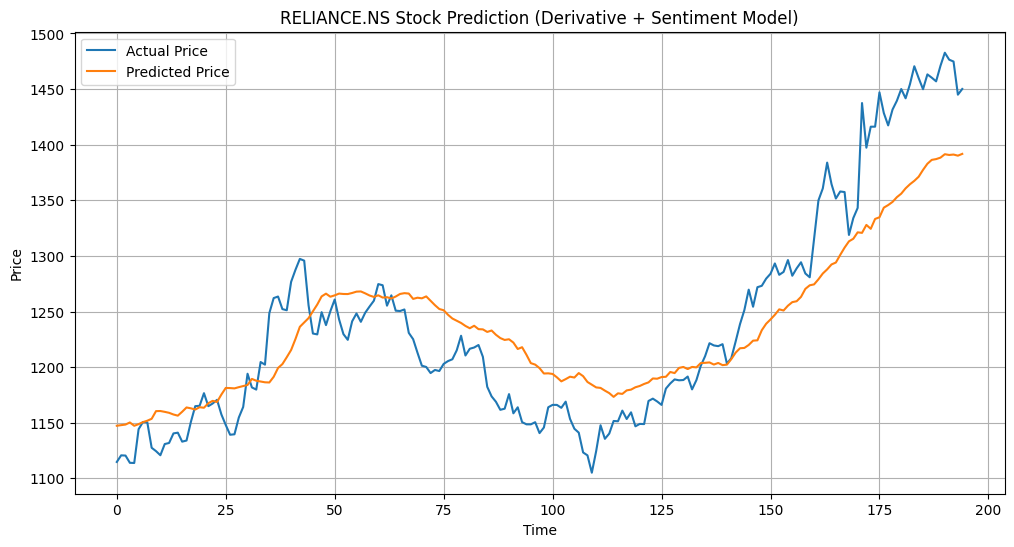


✅ Results saved to CSV!


In [6]:
# ============================================
# 📌 1. IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# 📌 2. PARAMETERS (EASY TO MODIFY)
# ============================================
TICKER = "RELIANCE.NS"
START_DATE = "2020-01-01"
END_DATE = "2024-03-01"
WINDOW_SIZE = 60
EPOCHS = 30
BATCH_SIZE = 32

# ============================================
# 📌 3. FETCH STOCK DATA
# ============================================
df = yf.download(TICKER, start=START_DATE, end=END_DATE)
df = df[['Close']].dropna()
df.reset_index(inplace=True)

# ============================================
# 📌 4. SIMULATED SENTIMENT (REPLACE WITH FinBERT)
# ============================================
np.random.seed(42)
df['Sentiment'] = np.random.normal(0, 0.2, len(df)).cumsum()
df['Sentiment'] = (df['Sentiment'] - df['Sentiment'].min()) / (df['Sentiment'].max() - df['Sentiment'].min())
df['Sentiment'] = df['Sentiment'] * 2 - 1  # scale to [-1,1]

# ============================================
# 📌 5. DERIVATIVE FEATURES
# ============================================

# First derivative (price velocity)
df['dP_dt'] = df['Close'].diff()

# Second derivative (price acceleration)
df['d2P_dt2'] = df['dP_dt'].diff()

# Sentiment derivatives
df['dS_dt'] = df['Sentiment'].diff()
df['d2S_dt2'] = df['dS_dt'].diff()

df.dropna(inplace=True)

# ============================================
# 📌 6. FEATURE MATRIX (AS PER PAPER)
# ============================================
features = ['Close', 'Sentiment', 'dP_dt', 'd2P_dt2', 'dS_dt', 'd2S_dt2']
data = df[features]

# ============================================
# 📌 7. SCALING
# ============================================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# ============================================
# 📌 8. CREATE SEQUENCES (LSTM INPUT)
# ============================================
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 0])  # Predict Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW_SIZE)

# ============================================
# 📌 9. TRAIN-TEST SPLIT
# ============================================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ============================================
# 📌 10. LSTM MODEL
# ============================================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# ============================================
# 📌 11. TRAIN MODEL
# ============================================
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ============================================
# 📌 12. PREDICTIONS
# ============================================
pred = model.predict(X_test)

# Inverse scaling
def inverse_transform(predictions, original_data):
    dummy = np.zeros((len(predictions), original_data.shape[1]))
    dummy[:, 0] = predictions[:, 0]
    return scaler.inverse_transform(dummy)[:, 0]

pred_prices = inverse_transform(pred, data.values)
actual_prices = inverse_transform(y_test.reshape(-1,1), data.values)

# ============================================
# 📌 13. EVALUATION METRICS
# ============================================
mae = mean_absolute_error(actual_prices, pred_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
r2 = r2_score(actual_prices, pred_prices)

print("\n📊 Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# ============================================
# 📌 14. TRADING SIGNALS (DERIVATIVE BASED)
# ============================================
signals = []

for i in range(1, len(pred_prices)):
    if pred_prices[i] > pred_prices[i-1]:
        signals.append("BUY")
    elif pred_prices[i] < pred_prices[i-1]:
        signals.append("SELL")
    else:
        signals.append("HOLD")

signals.insert(0, "HOLD")

# ============================================
# 📌 15. RESULTS DATAFRAME
# ============================================
results = pd.DataFrame({
    'Actual': actual_prices,
    'Predicted': pred_prices,
    'Signal': signals
})

# ============================================
# 📌 16. PLOT RESULTS
# ============================================
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(pred_prices, label='Predicted Price')
plt.title(f'{TICKER} Stock Prediction (Derivative + Sentiment Model)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# ============================================
# 📌 17. SAVE RESULTS
# ============================================
results.to_csv("derivative_stock_predictions.csv", index=False)

print("\n✅ Results saved to CSV!")